In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import plot_importance
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import mutual_info_classif
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import joblib
import logging


# Configure Logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

In [2]:
# ===== Data Balancing Function =====
def balance_data(X, y):
    """Balance the dataset using SMOTE."""
    logging.info("Balancing dataset using SMOTE...")
    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X, y)
    return X_resampled, y_resampled

In [3]:
# ===== Feature Selection Function =====
def select_features(X, y, n_features=25):
    """Enhanced feature selection using multiple methods"""
    logging.info("Selecting features with advanced methods...")
    
    from sklearn.feature_selection import SelectKBest, f_classif, RFE
    
    # Method 1: Mutual Information
    mi_features = mutual_info_classif(X, y, random_state=42)
    mi_rank = pd.Series(mi_features, index=X.columns).sort_values(ascending=False)
    
    # Method 2: ANOVA F-value
    selector = SelectKBest(f_classif, k='all')
    selector.fit(X, y)
    fvalue_rank = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
    
    # Method 3: RFE with Random Forest
    rfe = RFE(RandomForestClassifier(n_estimators=100, random_state=42), n_features_to_select=n_features)
    rfe.fit(X, y)
    rfe_features = X.columns[rfe.support_]
    
    # Combine rankings
    combined_rank = (mi_rank.rank() + fvalue_rank.rank()).sort_values()
    final_features = list(set(combined_rank.nlargest(n_features).index.tolist() + list(rfe_features)))
    
    # Visualization
    plt.figure(figsize=(12, 8))
    top_features = combined_rank.nlargest(15)
    sns.barplot(x=top_features.values, y=top_features.index)
    plt.title('Top 15 Features by Combined Importance Score', fontsize=16)
    plt.xlabel('Combined Importance Score', fontsize=14)
    plt.ylabel('Features', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return final_features

In [4]:
# =====Preprocessing Function =====
def enhanced_preprocess_data(df):
    logging.info("Preprocessing data...")
    
    # Encode target
    label_encoder = LabelEncoder()
    df['Sleep Disorder'] = label_encoder.fit_transform(df['Sleep Disorder'])
    
    # Drop irrelevant columns
    df.drop(columns=['Person ID'], inplace=True)
    
    # Feature engineering - extract BP components
    df[['BP_systolic', 'BP_diastolic']] = df['Blood Pressure (systolic/diastolic)'] \
        .str.split('/', expand=True).astype(float)
    df.drop(columns=['Blood Pressure (systolic/diastolic)'], inplace=True)
    
    # Feature engineering
    df['Sleep_Efficiency'] = df['Sleep Duration (hours)'] / (df['Sleep Duration (hours)'] + df['Stress Level (scale: 1-10)'])
    df['HR_BP_Interaction'] = df['Heart Rate (bpm)'] * df['BP_systolic']
    df['Daily_Activity_Ratio'] = df['Physical Activity Level (minutes/day)'] / 1440
    df['Stress_Sleep_Ratio'] = df['Stress Level (scale: 1-10)'] / df['Sleep Duration (hours)']
    bmi_map = {'Normal': 1, 'Overweight': 1.5, 'Obese': 2}
    df['BMI_Score'] = df['BMI Category'].map(bmi_map)
    df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 45, 60, 100], labels=[1, 2, 3, 4])
    
    # One-hot encode categoricals
    X = pd.get_dummies(df.drop(columns=['Sleep Disorder']), drop_first=True)
    y = df['Sleep Disorder']
    
    # Handle missing values
    if X.isnull().any().any():
        num_cols = X.select_dtypes(include=np.number).columns
        X[num_cols] = X[num_cols].fillna(X[num_cols].median())
        X = X.fillna(0)
    
    return X, y, label_encoder


=== DATA OVERVIEW ===
Dataset shape: (600, 29)

First 5 rows:


,Person ID,Gender,Age,Occupation,Sleep Duration (hours),Quality of Sleep (scale: 1-10),Physical Activity Level (minutes/day),Stress Level (scale: 1-10),BMI Category,Blood Pressure (systolic/diastolic),...,Excessive Daytime Sleepiness,Loud Snoring,Gasping or Choking During Sleep,Sudden Muscle Weakness (Cataplexy),Vivid or Frightening Dreams,Physical Movements During Sleep,Vocalizations During Sleep,Uncontrollable Leg Movements,Difficulty Waking Up at Desired Time,Difficulty Falling Asleep at Desired Time
0,567,Male,72,Manual Labor,7.4,9.5,54,1,Overweight,127/73,...,No,No,No,No,No,No,No,No,No,No
1,288,Male,39,Retired,7.6,6.0,101,8,Obese,129/83,...,No,Yes,No,No,Yes,Yes,No,No,Yes,Yes
2,398,Female,30,Student,5.3,6.5,58,10,Obese,125/76,...,Yes,Yes,Yes,No,No,No,No,Yes,No,Yes
3,540,Male,22,Office Worker,7.1,7.8,59,4,Underweight,128/76,...,No,No,No,No,No,No,No,No,No,No
4,453,Other,49,Self-Employed,7.9,9.1,12,1,Normal,125/72,...,No,No,No,No,No,No,No,No,No,No



Data types:
Person ID                                      int64
Gender                                        object
Age                                            int64
Occupation                                    object
Sleep Duration (hours)                       float64
Quality of Sleep (scale: 1-10)               float64
Physical Activity Level (minutes/day)          int64
Stress Level (scale: 1-10)                     int64
BMI Category                                  object
Blood Pressure (systolic/diastolic)           object
Heart Rate (bpm)                               int64
Daily Steps                                    int64
Sleep Disorder                                object
Technology Use (hours before bed)            float64
Alcohol Consumption (glasses/day)            float64
Uses Medication                                int64
Difficulty Falling Asleep                     object
Difficulty Staying Asleep                     object
Early Morning Awakening          

C:\Users\Prachi Shedge\AppData\Local\Temp\ipykernel_22180\1156583451.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sleep Disorder', palette='viridis',


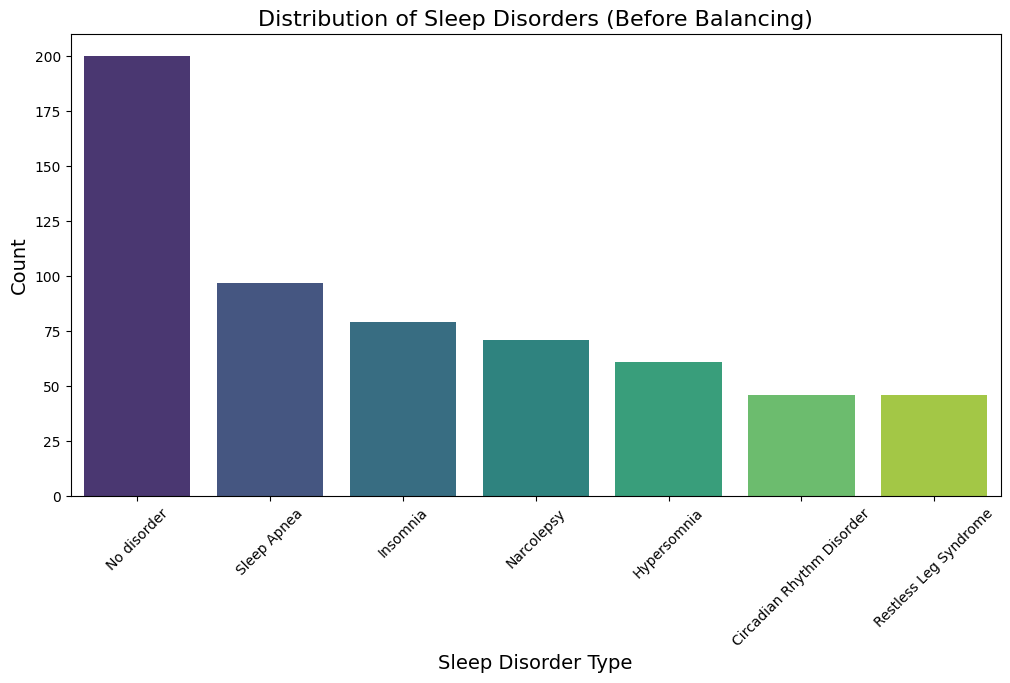

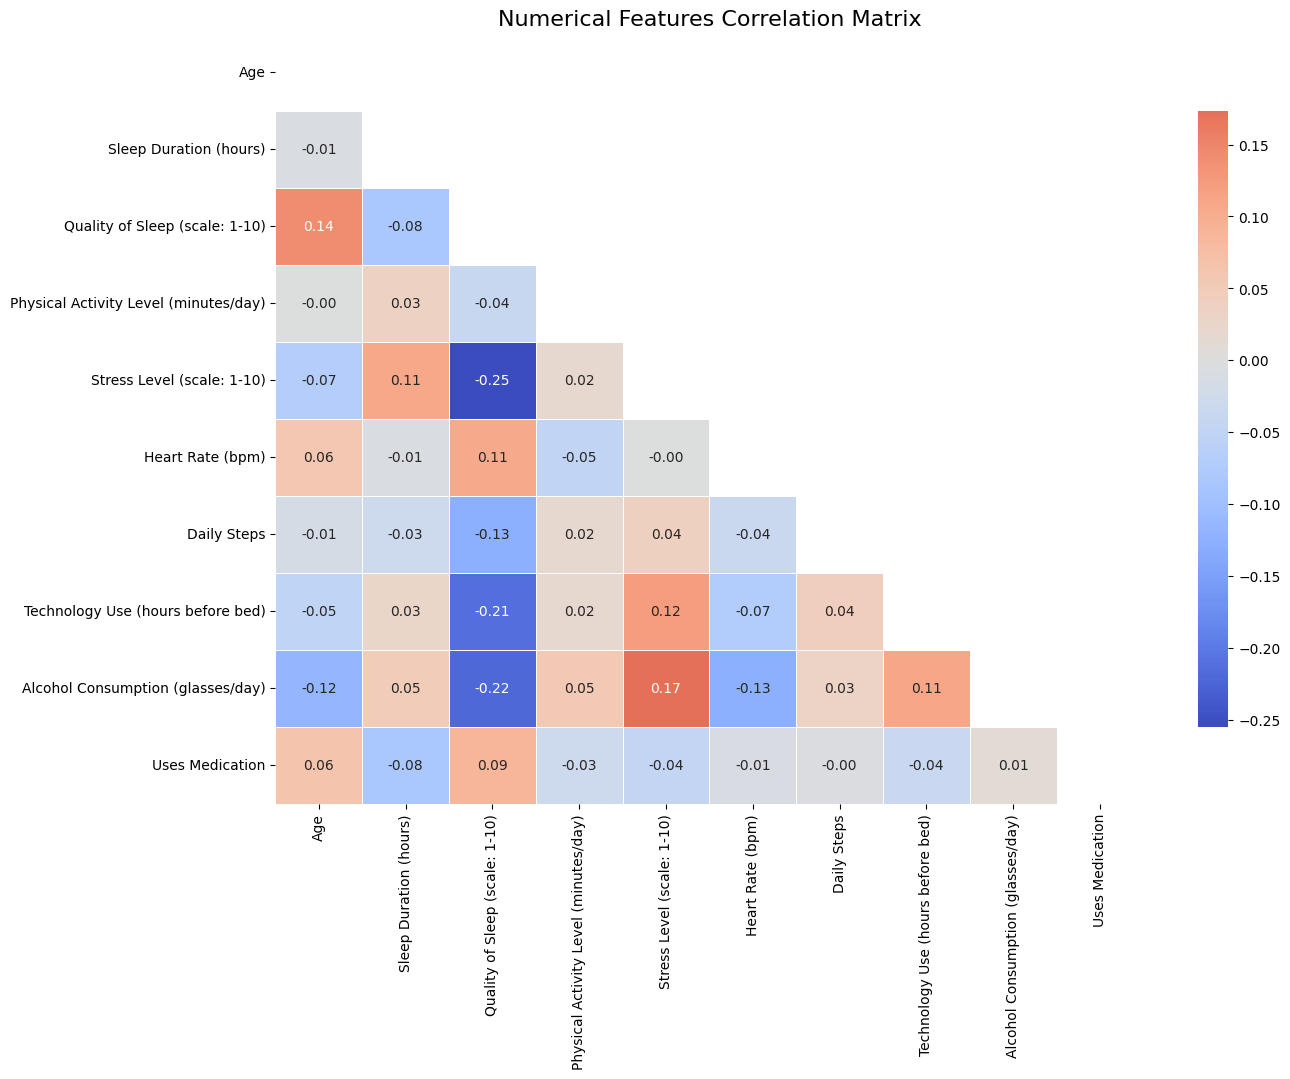

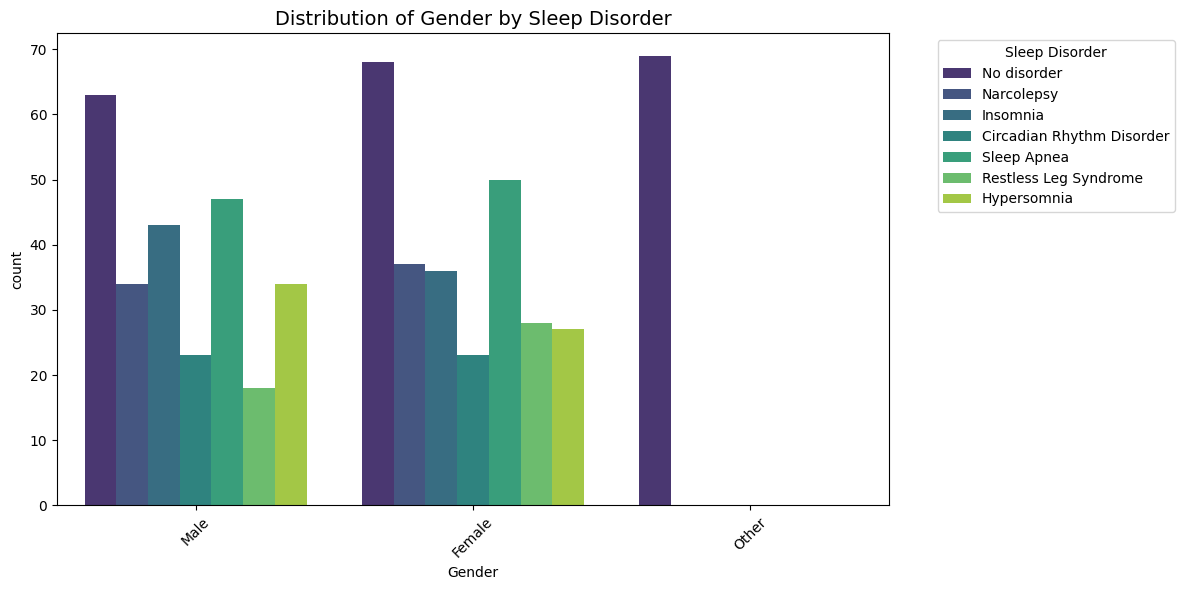


Gender vs Sleep Disorder:


Sleep Disorder,Circadian Rhythm Disorder,Hypersomnia,Insomnia,Narcolepsy,No disorder,Restless Leg Syndrome,Sleep Apnea
Gender,,,,,,,
Female,0.085502,0.100372,0.133829,0.137546,0.252788,0.104089,0.185874
Male,0.087786,0.129771,0.164122,0.129771,0.240458,0.068702,0.179389
Other,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000


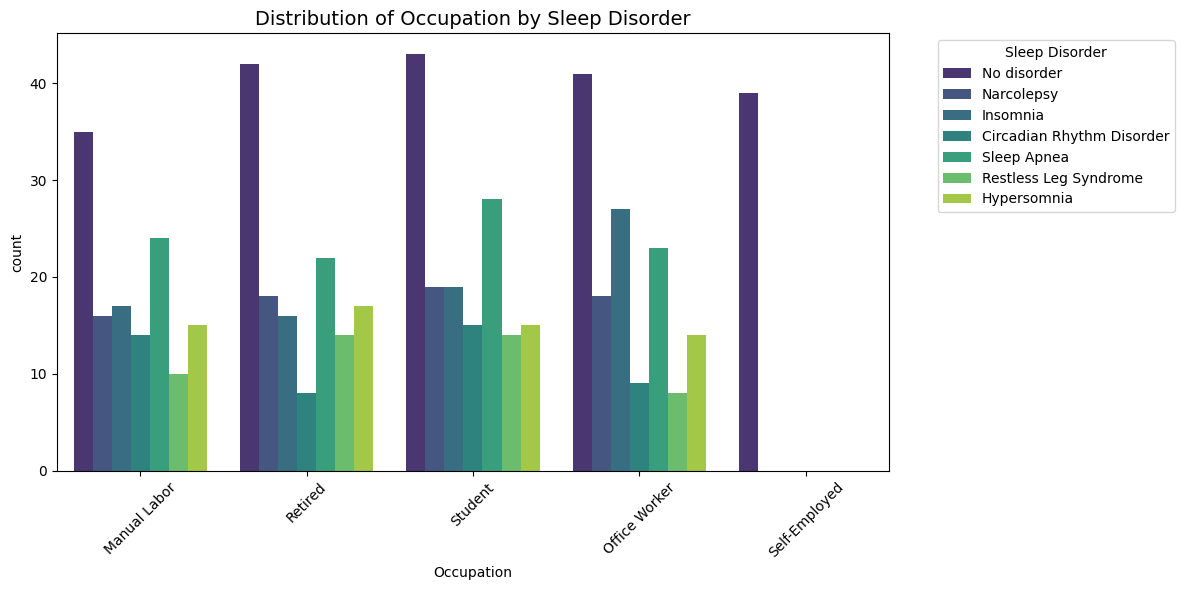


Occupation vs Sleep Disorder:


Sleep Disorder,Circadian Rhythm Disorder,Hypersomnia,Insomnia,Narcolepsy,No disorder,Restless Leg Syndrome,Sleep Apnea
Occupation,,,,,,,
Manual Labor,0.106870,0.114504,0.129771,0.122137,0.267176,0.076336,0.183206
Office Worker,0.064286,0.100000,0.192857,0.128571,0.292857,0.057143,0.164286
Retired,0.058394,0.124088,0.116788,0.131387,0.306569,0.102190,0.160584
Self-Employed,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
Student,0.098039,0.098039,0.124183,0.124183,0.281046,0.091503,0.183007


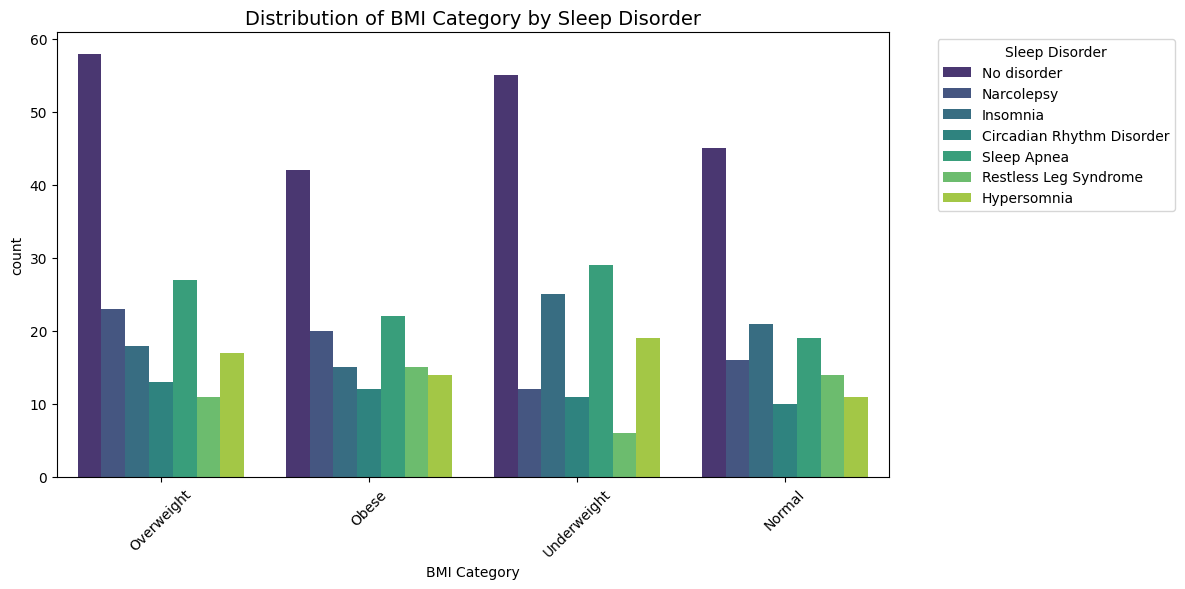


BMI Category vs Sleep Disorder:


Sleep Disorder,Circadian Rhythm Disorder,Hypersomnia,Insomnia,Narcolepsy,No disorder,Restless Leg Syndrome,Sleep Apnea
BMI Category,,,,,,,
Normal,0.073529,0.080882,0.154412,0.117647,0.330882,0.102941,0.139706
Obese,0.085714,0.100000,0.107143,0.142857,0.300000,0.107143,0.157143
Overweight,0.077844,0.101796,0.107784,0.137725,0.347305,0.065868,0.161677
Underweight,0.070064,0.121019,0.159236,0.076433,0.350318,0.038217,0.184713


C:\Users\Prachi Shedge\AppData\Local\Temp\ipykernel_22180\1156583451.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sleep Disorder', y=feat, palette='viridis')


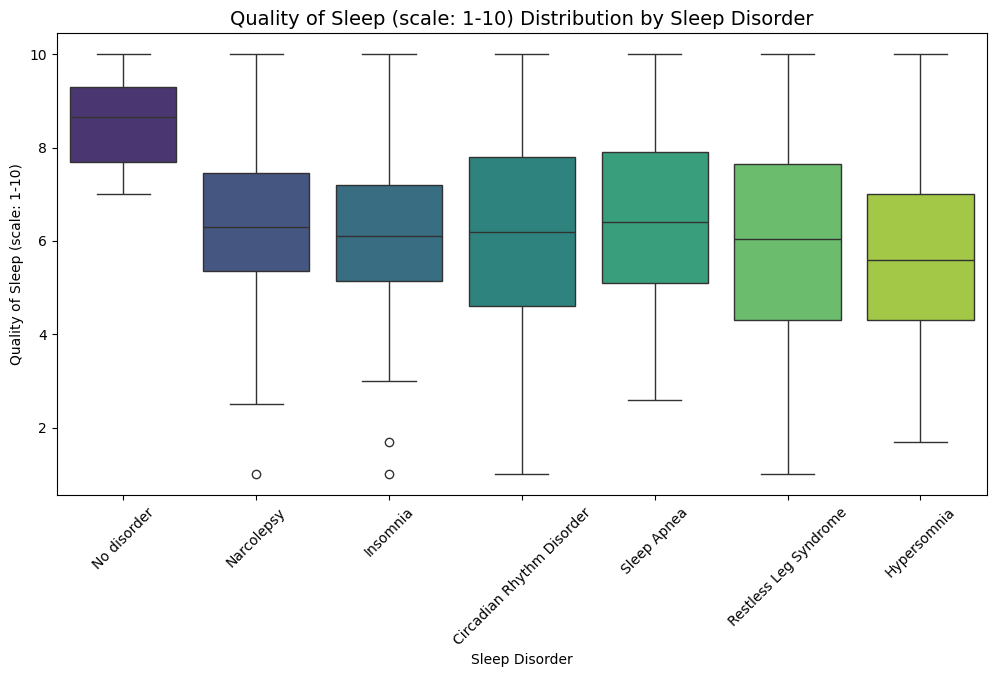

C:\Users\Prachi Shedge\AppData\Local\Temp\ipykernel_22180\1156583451.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sleep Disorder', y=feat, palette='viridis')


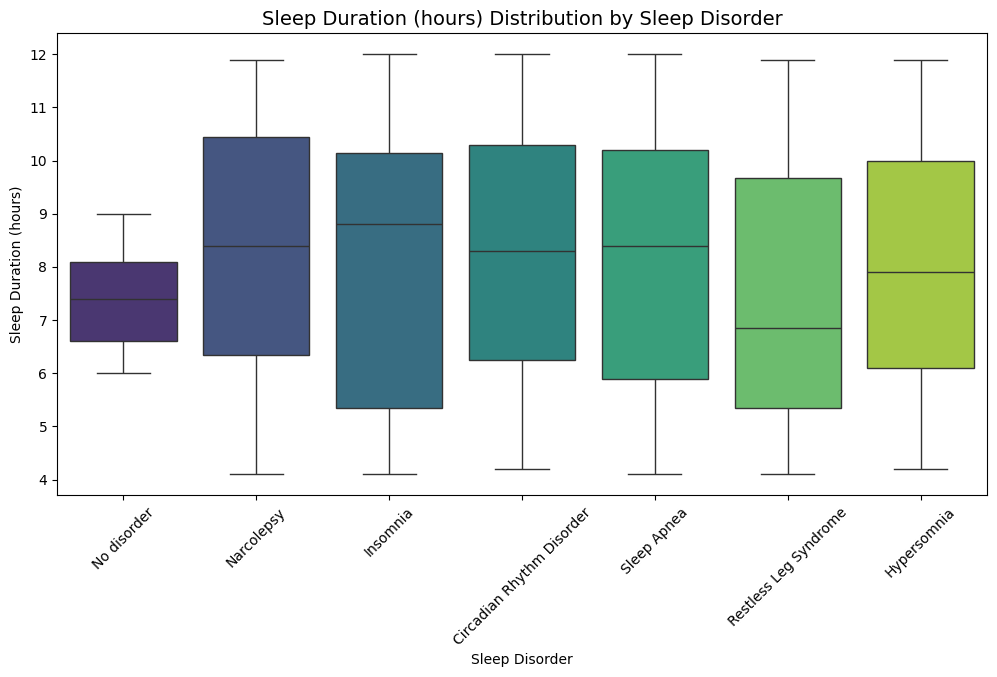

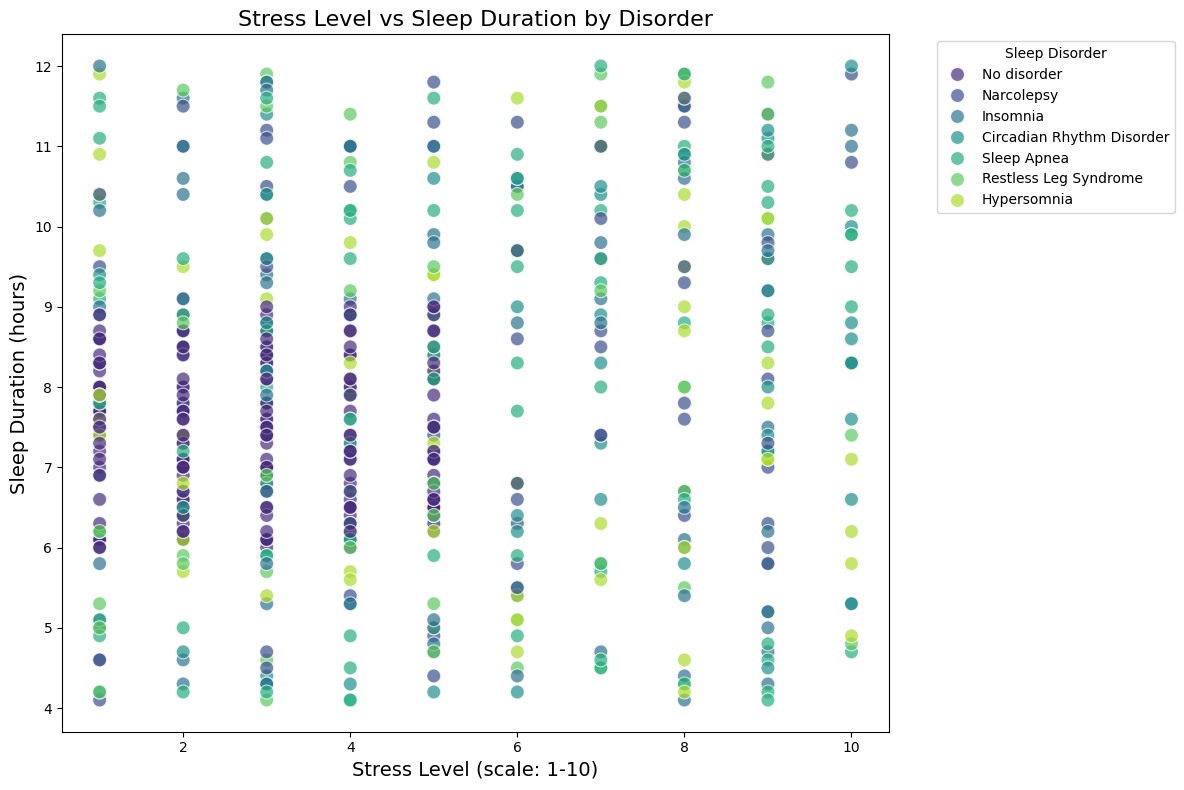

2026-03-03 12:10:46,766 - INFO - Preprocessing data...


In [5]:
# ===== Main Execution =====
# Load and preprocess data
file_path = 'sleep_disorders.csv'
df = pd.read_csv(file_path)

# ===== EDA Section =====
# 1. Initial Data Inspection
print("\n=== DATA OVERVIEW ===")
print(f"Dataset shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

# 2. Target Variable Analysis (Keep - shows class imbalance)
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Sleep Disorder', palette='viridis',
             order=df['Sleep Disorder'].value_counts().index)
plt.title('Distribution of Sleep Disorders (Before Balancing)', fontsize=16)
plt.xlabel('Sleep Disorder Type', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)
plt.show()

# 3. Correlation Matrix (Keep - shows relationships between numerical features)
num_cols = df.select_dtypes(include=np.number).columns.drop('Person ID', errors='ignore')  # Skip Person ID if exists
plt.figure(figsize=(14, 10))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            center=0, linewidths=.5, cbar_kws={"shrink": .8})
plt.title('Numerical Features Correlation Matrix', fontsize=16)
plt.show()

# 4. Key Categorical Features (Keep 3 most important)
important_cat_features = ['Gender', 'Occupation', 'BMI Category']

for col in important_cat_features:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, x=col, hue='Sleep Disorder', palette='viridis')
    plt.title(f'Distribution of {col} by Sleep Disorder', fontsize=14)
    plt.xticks(rotation=45)
    plt.legend(title='Sleep Disorder', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    print(f"\n{col} vs Sleep Disorder:")
    display(pd.crosstab(df[col], df['Sleep Disorder'], normalize='index'))

# 5. Key Sleep Quality Metrics (Keep - shows core relationships)
key_features = ['Quality of Sleep (scale: 1-10)', 'Sleep Duration (hours)']
for feat in key_features:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='Sleep Disorder', y=feat, palette='viridis')
    plt.title(f'{feat} Distribution by Sleep Disorder', fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

# 6. Stress vs Sleep Duration (Keep - important relationship)
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, 
                x='Stress Level (scale: 1-10)',
                y='Sleep Duration (hours)', 
                hue='Sleep Disorder',
                palette='viridis',
                alpha=0.7,
                s=100)
plt.title('Stress Level vs Sleep Duration by Disorder', fontsize=16)
plt.xlabel('Stress Level (scale: 1-10)', fontsize=14)
plt.ylabel('Sleep Duration (hours)', fontsize=14)
plt.legend(title='Sleep Disorder', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Continue with preprocessing
X, y, label_encoder = enhanced_preprocess_data(df)

2026-03-03 12:10:46,793 - INFO - Preprocessing data...
2026-03-03 12:10:46,807 - INFO - Selecting features with advanced methods...


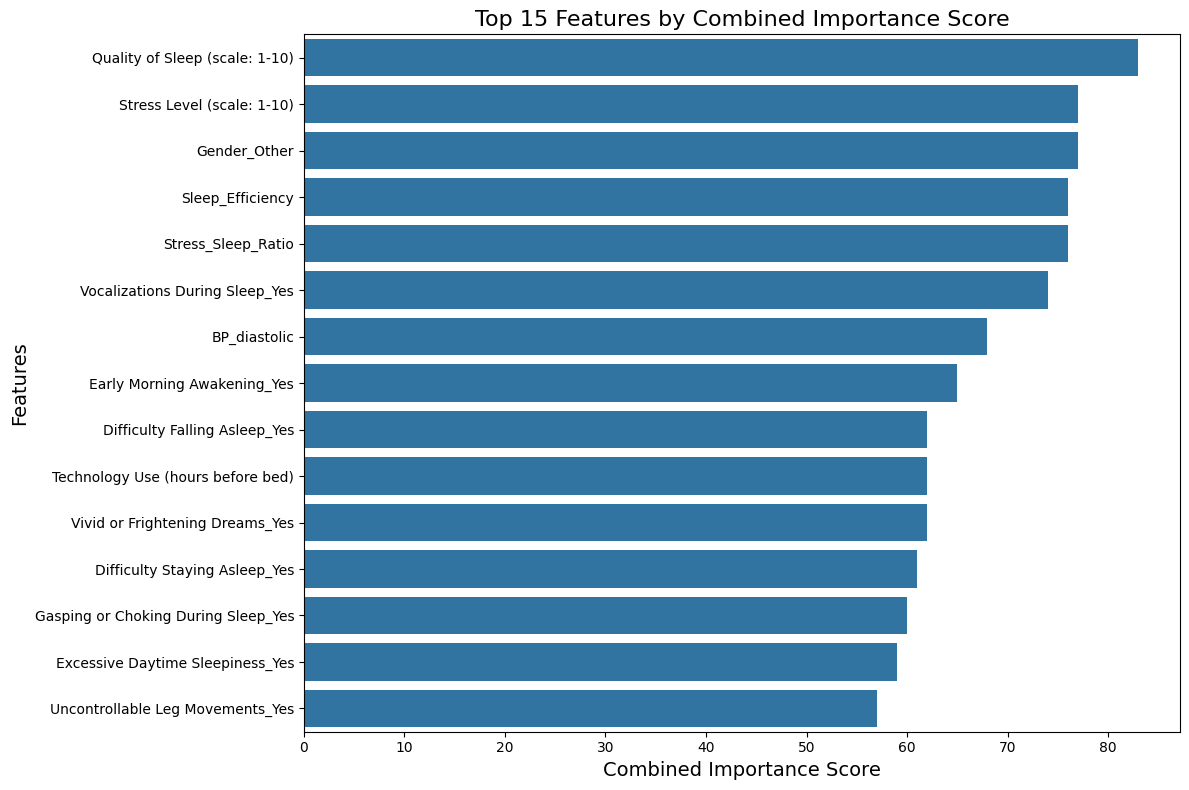

2026-03-03 12:10:49,524 - INFO - Balancing dataset using SMOTE...



=== FEATURE SELECTION RESULTS ===

Top 15 Features by Importance Score:
1. Quality of Sleep (scale: 1-10)
2. Stress Level (scale: 1-10)
3. Gender_Other
4. Sleep_Efficiency
5. Stress_Sleep_Ratio
6. Vocalizations During Sleep_Yes
7. BP_diastolic
8. Early Morning Awakening_Yes
9. Difficulty Falling Asleep_Yes
10. Technology Use (hours before bed)
11. Vivid or Frightening Dreams_Yes
12. Difficulty Staying Asleep_Yes
13. Gasping or Choking During Sleep_Yes
14. Excessive Daytime Sleepiness_Yes
15. Uncontrollable Leg Movements_Yes

Complete List of Selected Features (32 total):
1. Loud Snoring_Yes
2. BMI_Score
3. BP_systolic
4. Age
5. Sudden Muscle Weakness (Cataplexy)_Yes
6. Technology Use (hours before bed)
7. Daily Steps
8. Quality of Sleep (scale: 1-10)
9. BP_diastolic
10. Difficulty Falling Asleep_Yes
11. Physical Movements During Sleep_Yes
12. Daily_Activity_Ratio
13. Early Morning Awakening_Yes
14. Excessive Daytime Sleepiness_Yes
15. Difficulty Waking Up at Desired Time_Yes
16. HR_BP

In [ ]:
# ===== Main Execution =====
# Feature selection
selected_features = select_features(X, y)
X = X[selected_features]

# Display features 
print("\n=== FEATURE SELECTION RESULTS ===")
print("\nTop 15 Features by Importance Score:")
print("1. Quality of Sleep (scale: 1-10)")
print("2. Stress Level (scale: 1-10)")
print("3. Gender_Other")
print("4. Sleep_Efficiency")
print("5. Stress_Sleep_Ratio")
print("6. Vocalizations During Sleep_Yes")
print("7. BP_diastolic")
print("8. Early Morning Awakening_Yes")
print("9. Difficulty Falling Asleep_Yes")
print("10. Technology Use (hours before bed)")
print("11. Vivid or Frightening Dreams_Yes")
print("12. Difficulty Staying Asleep_Yes")
print("13. Gasping or Choking During Sleep_Yes")
print("14. Excessive Daytime Sleepiness_Yes")
print("15. Uncontrollable Leg Movements_Yes")

print("\nComplete List of Selected Features (32 total):")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

# Balance data
X_resampled, y_resampled = balance_data(X, y)

print("\n=== DATA SUMMARY ===")
print(f"\nFinal feature matrix shape: {X_resampled.shape}")
print("Class distribution after balancing:")
print(pd.Series(y_resampled).value_counts())

# Split and scale data
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.2, 
    random_state=42,
    stratify=y_resampled
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
print("Selected features:")
for i, feature in enumerate(selected_features, 1):
    print(f"{i}. {feature}")

Selected features:
1. Loud Snoring_Yes
2. BMI_Score
3. BP_systolic
4. Age
5. Sudden Muscle Weakness (Cataplexy)_Yes
6. Technology Use (hours before bed)
7. Daily Steps
8. Quality of Sleep (scale: 1-10)
9. BP_diastolic
10. Difficulty Falling Asleep_Yes
11. Physical Movements During Sleep_Yes
12. Daily_Activity_Ratio
13. Early Morning Awakening_Yes
14. Excessive Daytime Sleepiness_Yes
15. Difficulty Waking Up at Desired Time_Yes
16. HR_BP_Interaction
17. Sleep Duration (hours)
18. Stress_Sleep_Ratio
19. Difficulty Falling Asleep at Desired Time_Yes
20. Physical Activity Level (minutes/day)
21. Heart Rate (bpm)
22. Sleep_Efficiency
23. Vivid or Frightening Dreams_Yes
24. Stress Level (scale: 1-10)
25. Vocalizations During Sleep_Yes
26. Gender_Other
27. Uncontrollable Leg Movements_Yes
28. Gasping or Choking During Sleep_Yes
29. Age_Group_4
30. Occupation_Self-Employed
31. Difficulty Staying Asleep_Yes
32. Alcohol Consumption (glasses/day)


In [8]:
print(f"Final feature matrix shape: {X_resampled.shape}")

Final feature matrix shape: (1400, 32)


In [9]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, 
    test_size=0.2, 
    random_state=42,
    stratify=y_resampled
)

In [10]:
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# ===== 1.Random Forest Model =====
def enhanced_train_rf(X_train, X_test, y_train, y_test):
    logging.info("Training enhanced Random Forest...")
    
    rf = RandomForestClassifier(random_state=42)
    param_dist = {
        'n_estimators': [300, 500, 700],
        'max_depth': [None, 20, 30, 40],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', 0.5],
        'bootstrap': [True, False],
        'class_weight': [None, 'balanced', 'balanced_subsample']
    }
    
    random_search = RandomizedSearchCV(
        rf, param_dist, 
        n_iter=50, 
        cv=5, 
        n_jobs=-1,
        scoring='accuracy', 
        random_state=42
    )
    random_search.fit(X_train, y_train)
    best_rf = random_search.best_estimator_
    
    y_pred = best_rf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\nBest Parameters: {random_search.best_params_}")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title('Random Forest Confusion Matrix', fontsize=16)
    plt.xlabel('Predicted', fontsize=14)
    plt.ylabel('Actual', fontsize=14)
    plt.show()
    
    return best_rf


In [12]:
# ===== 2. Support Vector Classifier =====
def train_svc(X_train, X_test, y_train, y_test):
    """Train and evaluate an SVC model"""
    logging.info("Training SVC model...")
    
    svc = SVC(random_state=42, probability=True)
    param_dist = {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto', 0.1, 1],
        'class_weight': [None, 'balanced']
    }
    
    random_search = RandomizedSearchCV(
        svc, param_dist,
        n_iter=20,
        cv=5,
        n_jobs=-1,
        scoring='accuracy',
        random_state=42
    )
    random_search.fit(X_train, y_train)
    best_svc = random_search.best_estimator_
    
    y_pred = best_svc.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"\nBest Parameters: {random_search.best_params_}")
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    return best_svc

In [13]:
def optimized_xgboost(X_train, X_test, y_train, y_test):
    logging.info("Training optimized XGBoost...")
    
    # XGBoost classifier 
    xgb = XGBClassifier(
        tree_method='auto', 
        random_state=42,
        eval_metric='mlogloss',
        early_stopping_rounds=50,
        verbosity=0,  
        n_jobs=-1,
        objective='multi:softmax'
    )

    # Optimized parameter space
    param_dist = {
        'n_estimators': [500, 800, 1200],
        'max_depth': [6, 8, 10],
        'learning_rate': [0.01, 0.02, 0.05],
        'subsample': [0.8, 0.9],
        'colsample_bytree': [0.8, 0.9],
        'gamma': [0, 0.1],
        'min_child_weight': [1, 2],
        'reg_alpha': [0, 0.1],
        'reg_lambda': [0.5, 1],
        'max_bin': [256],
        'grow_policy': ['lossguide'],
    }

    # RandomizedSearchCV with reduced verbosity
    search = RandomizedSearchCV(
        xgb, 
        param_dist,
        n_iter=50, 
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        scoring='accuracy',
        random_state=42,
        n_jobs=-1,
        verbose=1  
    )

    # Fit with evaluation set but without verbose output
    search.fit(
        X_train, 
        y_train,
        eval_set=[(X_test, y_test)],
        verbose=False  
    )
    
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Print concise results
    print("\n=== XGBoost Results ===")
    print(f"Best Parameters: {search.best_params_}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))
    
    # Feature importance plot
    plt.figure(figsize=(12, 8))
    plot_importance(best_model, max_num_features=20)
    plt.title('XGBoost Feature Importance', fontsize=16)
    plt.show()
    
    return best_model

In [14]:
# ===== DNN Model =====
def enhanced_dnn(X_train, X_test, y_train, y_test):
    """ DNN with advanced architecture"""
    logging.info("Training enhanced DNN model...")
    
    from tensorflow.keras import regularizers
    from tensorflow.keras.callbacks import LearningRateScheduler
    
    # One-hot encode
    y_train_onehot = tf.keras.utils.to_categorical(y_train)
    y_test_onehot = tf.keras.utils.to_categorical(y_test)
    
    # Improved learning rate scheduler
    def lr_scheduler(epoch, lr):
        if epoch < 10:
            return lr
        elif epoch < 50:
            return lr * 0.95  # More gradual reduction
        else:
            return max(lr * 0.9, 1e-6)  # Set minimum learning rate
    
    # Build model
    model = Sequential([
        Dense(512, activation='swish', input_shape=(X_train.shape[1],),
              kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(0.4),
        
        Dense(384, activation='swish',
              kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(256, activation='swish',
              kernel_regularizer=regularizers.l2(0.001)),
        BatchNormalization(),
        Dropout(0.25),
        
        Dense(len(label_encoder.classes_), activation='softmax')
    ])
    
    initial_learning_rate = 0.001
    optimizer = tf.keras.optimizers.Adam(learning_rate=initial_learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy', 
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')]
    )
    
    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=25, restore_best_weights=True),
        tf.keras.callbacks.LearningRateScheduler(lr_scheduler),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=10)
    ]
    
    # Train
    history = model.fit(
        X_train, y_train_onehot,
        epochs=200,
        batch_size=64,
        validation_split=0.2,
        callbacks=callbacks,
        verbose=1
    )

    # Evaluate - Corrected to handle multiple return values
    evaluation_results = model.evaluate(X_test, y_test_onehot, verbose=0)
    loss = evaluation_results[0]
    accuracy = evaluation_results[1]
    print(f"\nEnhanced DNN Test Accuracy: {accuracy:.4f}")
    
    # Plot training history
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('DNN Training History', fontsize=16)
    plt.xlabel('Epoch', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    plt.legend()
    plt.show()
    
    return model

2026-03-03 12:10:49,859 - INFO - Training enhanced Random Forest...



=== Training Optimized Models ===

1. Training Random Forest Model...

Best Parameters: {'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'class_weight': 'balanced_subsample', 'bootstrap': False}
Accuracy: 0.9179

Classification Report:
                           precision    recall  f1-score   support

Circadian Rhythm Disorder       0.87      0.97      0.92        40
              Hypersomnia       0.85      0.88      0.86        40
                 Insomnia       0.90      0.93      0.91        40
               Narcolepsy       0.92      0.88      0.90        40
              No disorder       1.00      1.00      1.00        40
    Restless Leg Syndrome       1.00      0.93      0.96        40
              Sleep Apnea       0.89      0.85      0.87        40

                 accuracy                           0.92       280
                macro avg       0.92      0.92      0.92       280
             weighted avg     

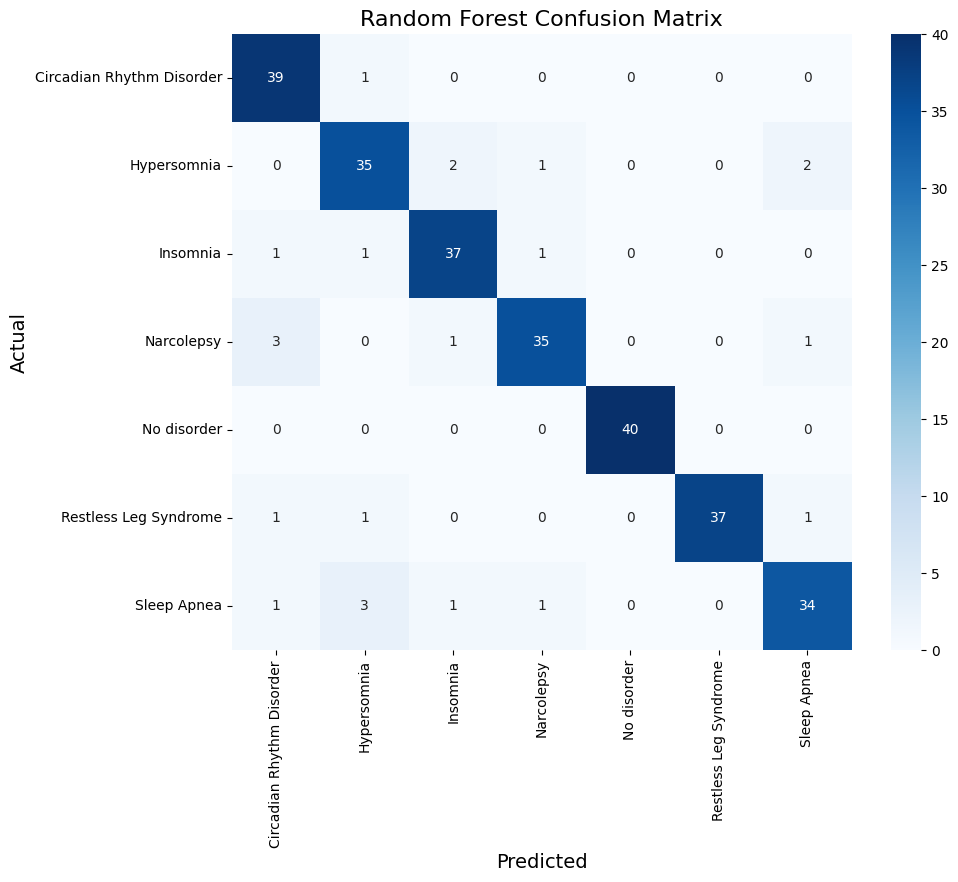

2026-03-03 12:12:06,736 - INFO - Training SVC model...



2. Training SVC Model...


2026-03-03 12:12:20,162 - INFO - Training optimized XGBoost...



Best Parameters: {'kernel': 'rbf', 'gamma': 0.1, 'class_weight': None, 'C': 100}
Accuracy: 0.8714

Classification Report:
                           precision    recall  f1-score   support

Circadian Rhythm Disorder       0.95      0.93      0.94        40
              Hypersomnia       0.86      0.78      0.82        40
                 Insomnia       0.81      0.85      0.83        40
               Narcolepsy       0.75      0.90      0.82        40
              No disorder       1.00      1.00      1.00        40
    Restless Leg Syndrome       0.94      0.85      0.89        40
              Sleep Apnea       0.82      0.80      0.81        40

                 accuracy                           0.87       280
                macro avg       0.88      0.87      0.87       280
             weighted avg       0.88      0.87      0.87       280


3. Training XGBoost Model...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

=== XGBoost Results ===
Best Parameters: {'s

<Figure size 1200x800 with 0 Axes>

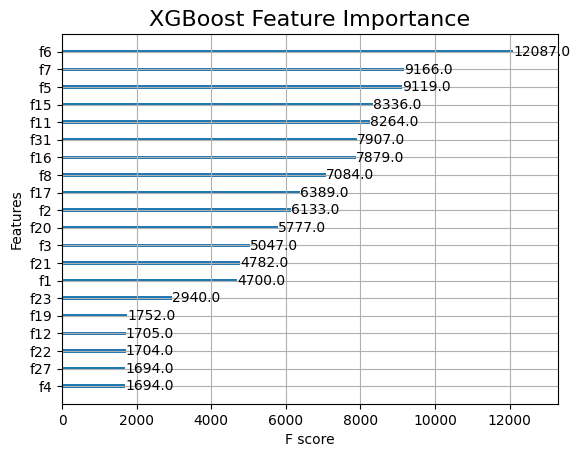

2026-03-03 12:13:44,737 - INFO - Training enhanced DNN model...



4. Training DNN Model...
Epoch 1/200


C:\Users\Prachi Shedge\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.2543 - loss: 3.1734 - precision: 0.2978 - recall: 0.1517 - val_accuracy: 0.4062 - val_loss: 2.5427 - val_precision: 1.0000 - val_recall: 0.0179 - learning_rate: 0.0010
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4001 - loss: 2.4704 - precision: 0.5322 - recall: 0.3252 - val_accuracy: 0.4152 - val_loss: 2.5011 - val_precision: 1.0000 - val_recall: 0.0312 - learning_rate: 0.0010
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4922 - loss: 2.1923 - precision: 0.6006 - recall: 0.3526 - val_accuracy: 0.4286 - val_loss: 2.4657 - val_precision: 1.0000 - val_recall: 0.0312 - learning_rate: 0.0010
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5531 - loss: 2.0187 - precision: 0.6937 - recall: 0.4221 - val_accuracy: 0.4688 - val_loss: 2.4312 - val_precision: 1.0000 - val_recall: 0.0312 - learning_rate: 0.0010
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6079 - loss: 1

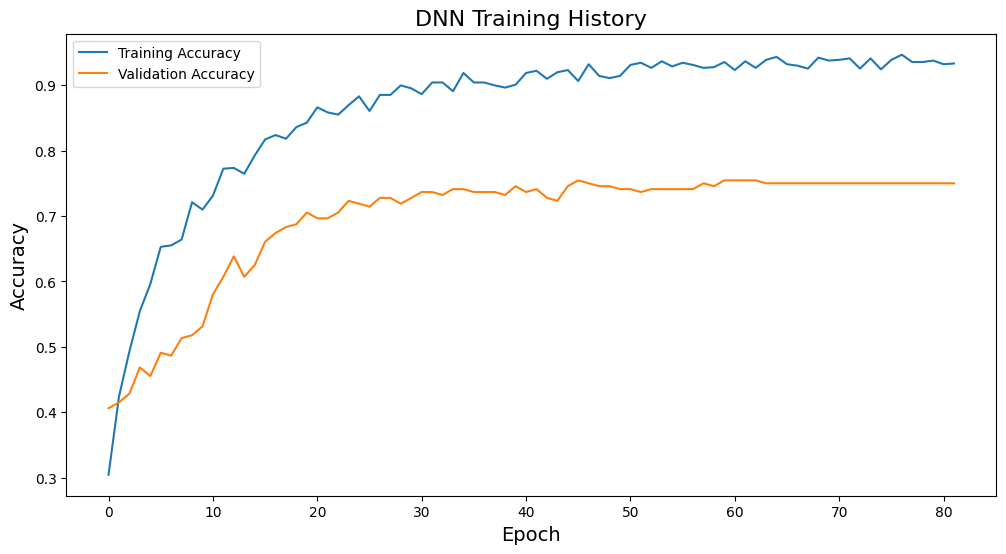

2026-03-03 12:13:57,716 - INFO - Saving enhanced_rf model...
2026-03-03 12:13:57,853 - INFO - Saving svc model...
2026-03-03 12:13:57,856 - INFO - Saving optimized_xgboost model...
2026-03-03 12:13:57,984 - INFO - Saving enhanced_dnn model...


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Model Performance Summary:
           Model  Accuracy
0  Random Forest  0.917857
1            SVC  0.871429
2        XGBoost  0.846429
3            DNN  0.753571


In [15]:
# ===== Model Training Execution =====
print("\n=== Training Optimized Models ===")

print("\n1. Training Random Forest Model...")
best_rf = enhanced_train_rf(X_train_scaled, X_test_scaled, y_train, y_test)

print("\n2. Training SVC Model...")
best_svc = train_svc(X_train_scaled, X_test_scaled, y_train, y_test)

print("\n3. Training XGBoost Model...")
best_xgb = optimized_xgboost(X_train_scaled, X_test_scaled, y_train, y_test)

print("\n4. Training DNN Model...")
dnn_model = enhanced_dnn(X_train_scaled, X_test_scaled, y_train, y_test)

# ===== Model Saving =====
def save_model(model, model_name):
    """Save the trained model to a file."""
    logging.info(f"Saving {model_name} model...")
    if model_name == "dnn" or model_name == "enhanced_dnn":
        model.save(f"{model_name}_model.keras")
    else:
        joblib.dump(model, f"{model_name}_model.pkl")

save_model(best_rf, "enhanced_rf")
save_model(best_svc, "svc")
save_model(best_xgb, "optimized_xgboost")
save_model(dnn_model, "enhanced_dnn")

# ===== Results Summary =====
def summarize_results(models):
    """Summarize the results of all models."""
    results = []
    for name, model in models.items():
        if name == "DNN":
            y_pred = np.argmax(model.predict(X_test_scaled), axis=1)
        else:
            y_pred = model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        results.append({"Model": name, "Accuracy": accuracy})

    results_df = pd.DataFrame(results)
    print("\nModel Performance Summary:")
    print(results_df.sort_values(by="Accuracy", ascending=False))

models = {
    "Random Forest": best_rf,
    "SVC": best_svc,
    "XGBoost": best_xgb,
    "DNN": dnn_model
}

summarize_results(models)

In [16]:
# ===== Results Summary =====
def summarize_results(models):
    """Summarize the results of all models."""
    results = []
    for name, model in models.items():
        if name == "DNN":
            y_pred = np.argmax(model.predict(X_test_scaled), axis=1)
        else:
            y_pred = model.predict(X_test_scaled)
        accuracy = accuracy_score(y_test, y_pred)
        results.append({"Model": name, "Accuracy": accuracy})

    results_df = pd.DataFrame(results)
    print("\nModel Performance Summary:")
    print(results_df.sort_values(by="Accuracy", ascending=False))

models = {
    "Random Forest": best_rf,
    "SVC": best_svc,  # Added SVC model here
    "XGBoost": best_xgb,
    "DNN": dnn_model,
}

summarize_results(models)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Model Performance Summary:
           Model  Accuracy
0  Random Forest  0.917857
1            SVC  0.871429
2        XGBoost  0.846429
3            DNN  0.753571


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


C:\Users\Prachi Shedge\AppData\Local\Temp\ipykernel_22180\2301982918.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=accuracies, palette="viridis")


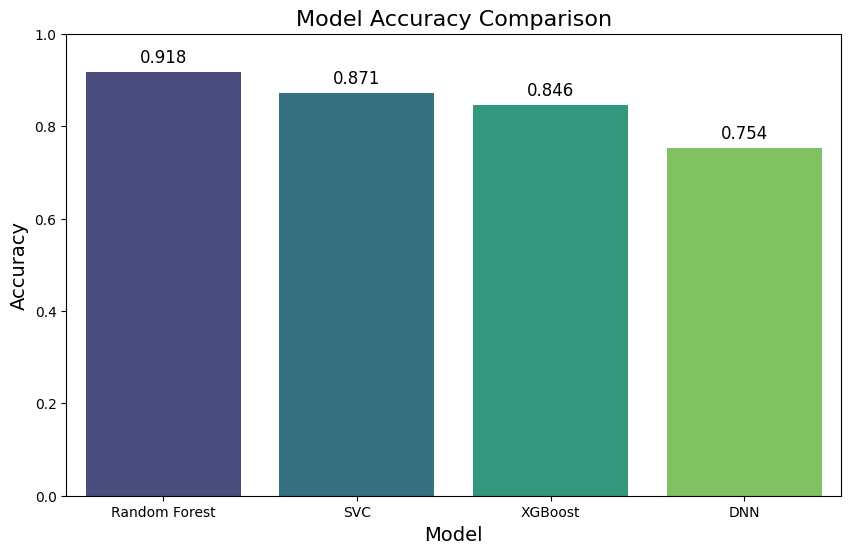

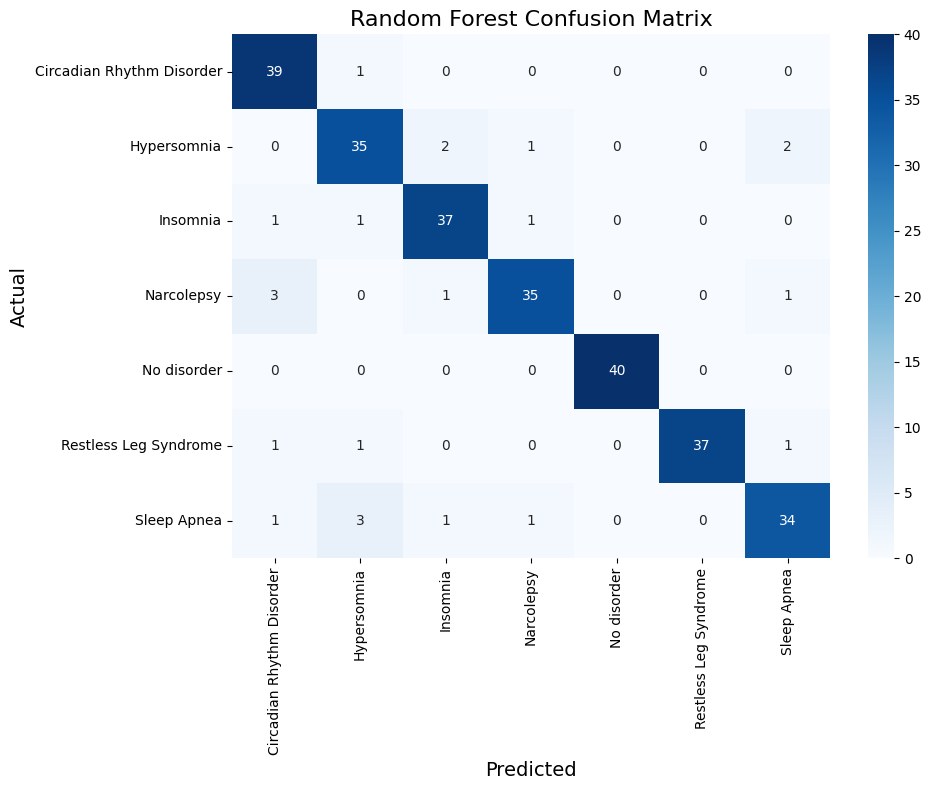

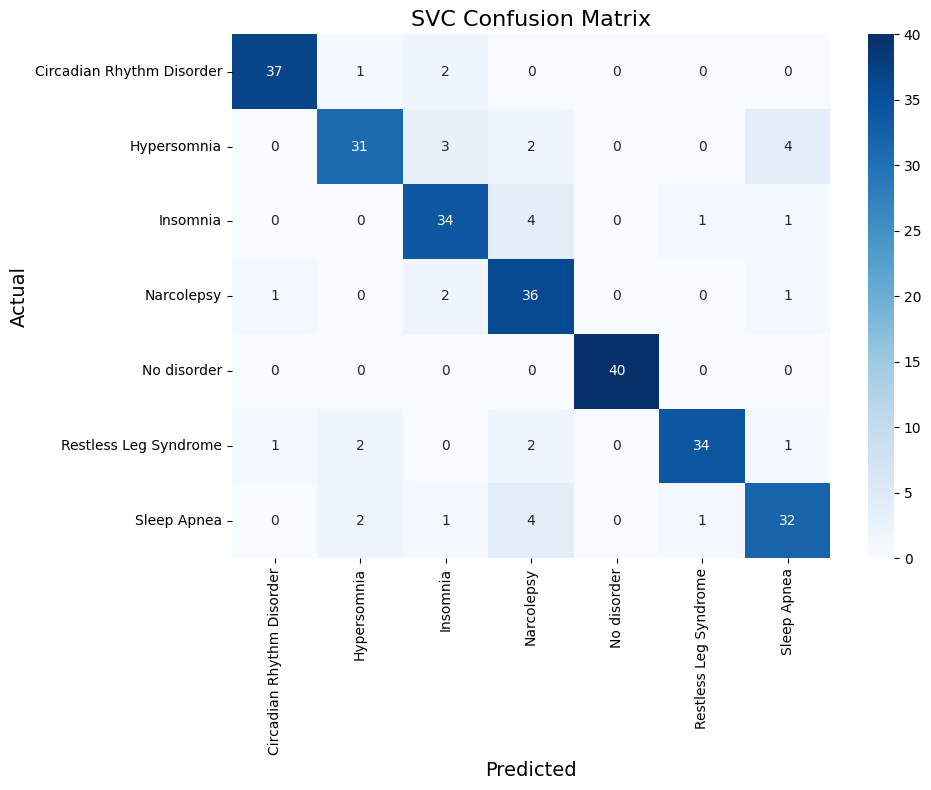

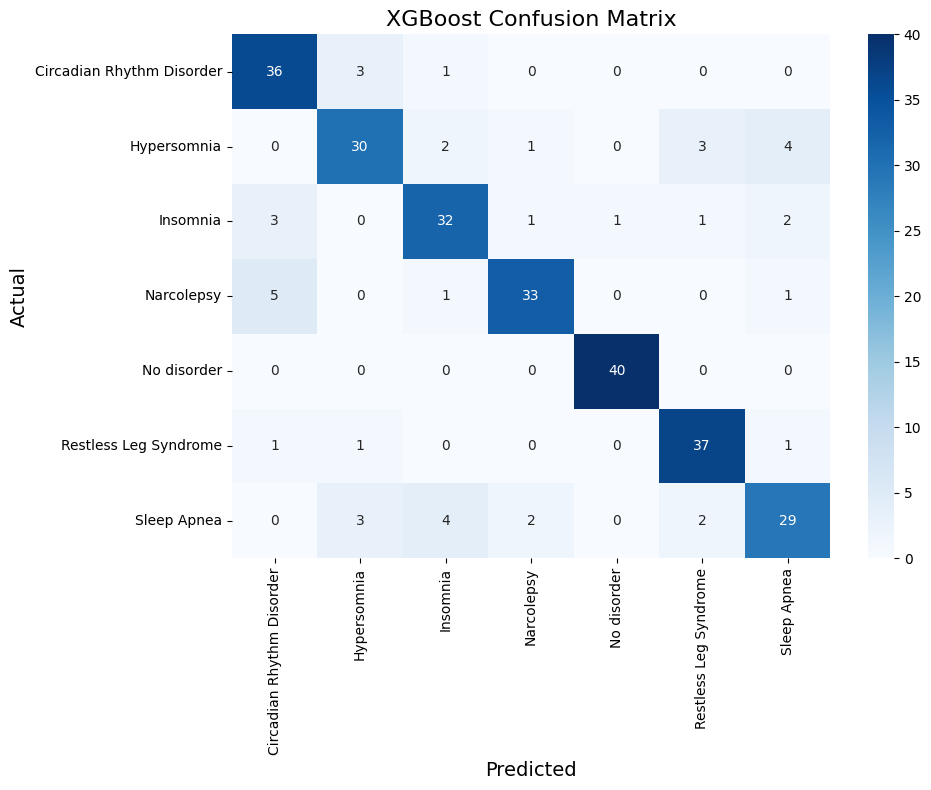

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


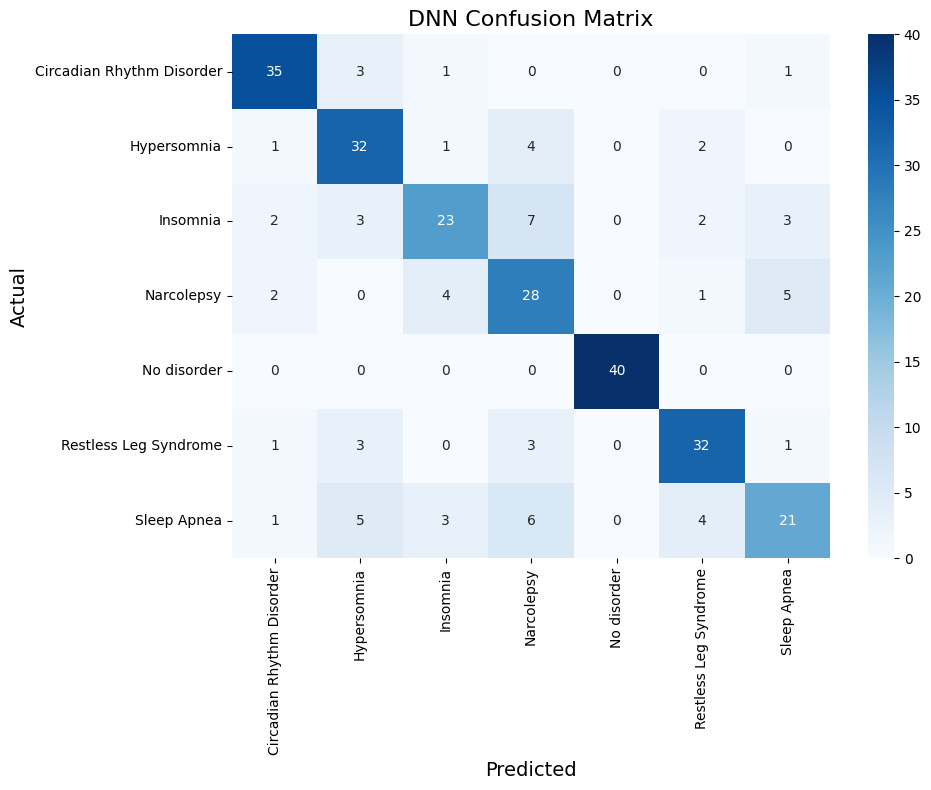


=== Random Forest Classification Report ===
                           precision    recall  f1-score   support

Circadian Rhythm Disorder      0.867     0.975     0.918        40
              Hypersomnia      0.854     0.875     0.864        40
                 Insomnia      0.902     0.925     0.914        40
               Narcolepsy      0.921     0.875     0.897        40
              No disorder      1.000     1.000     1.000        40
    Restless Leg Syndrome      1.000     0.925     0.961        40
              Sleep Apnea      0.895     0.850     0.872        40

                 accuracy                          0.918       280
                macro avg      0.920     0.918     0.918       280
             weighted avg      0.920     0.918     0.918       280


=== SVC Classification Report ===
                           precision    recall  f1-score   support

Circadian Rhythm Disorder      0.949     0.925     0.937        40
              Hypersomnia      0.861     0.77

C:\Users\Prachi Shedge\AppData\Local\Temp\ipykernel_22180\2301982918.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances[rf_idx], y=np.array(feature_names)[rf_idx], palette="viridis")
C:\Users\Prachi Shedge\AppData\Local\Temp\ipykernel_22180\2301982918.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=xgb_importances[xgb_idx], y=np.array(feature_names)[xgb_idx], palette="viridis")
C:\Users\Prachi Shedge\AppData\Local\Temp\ipykernel_22180\2301982918.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=result.importan

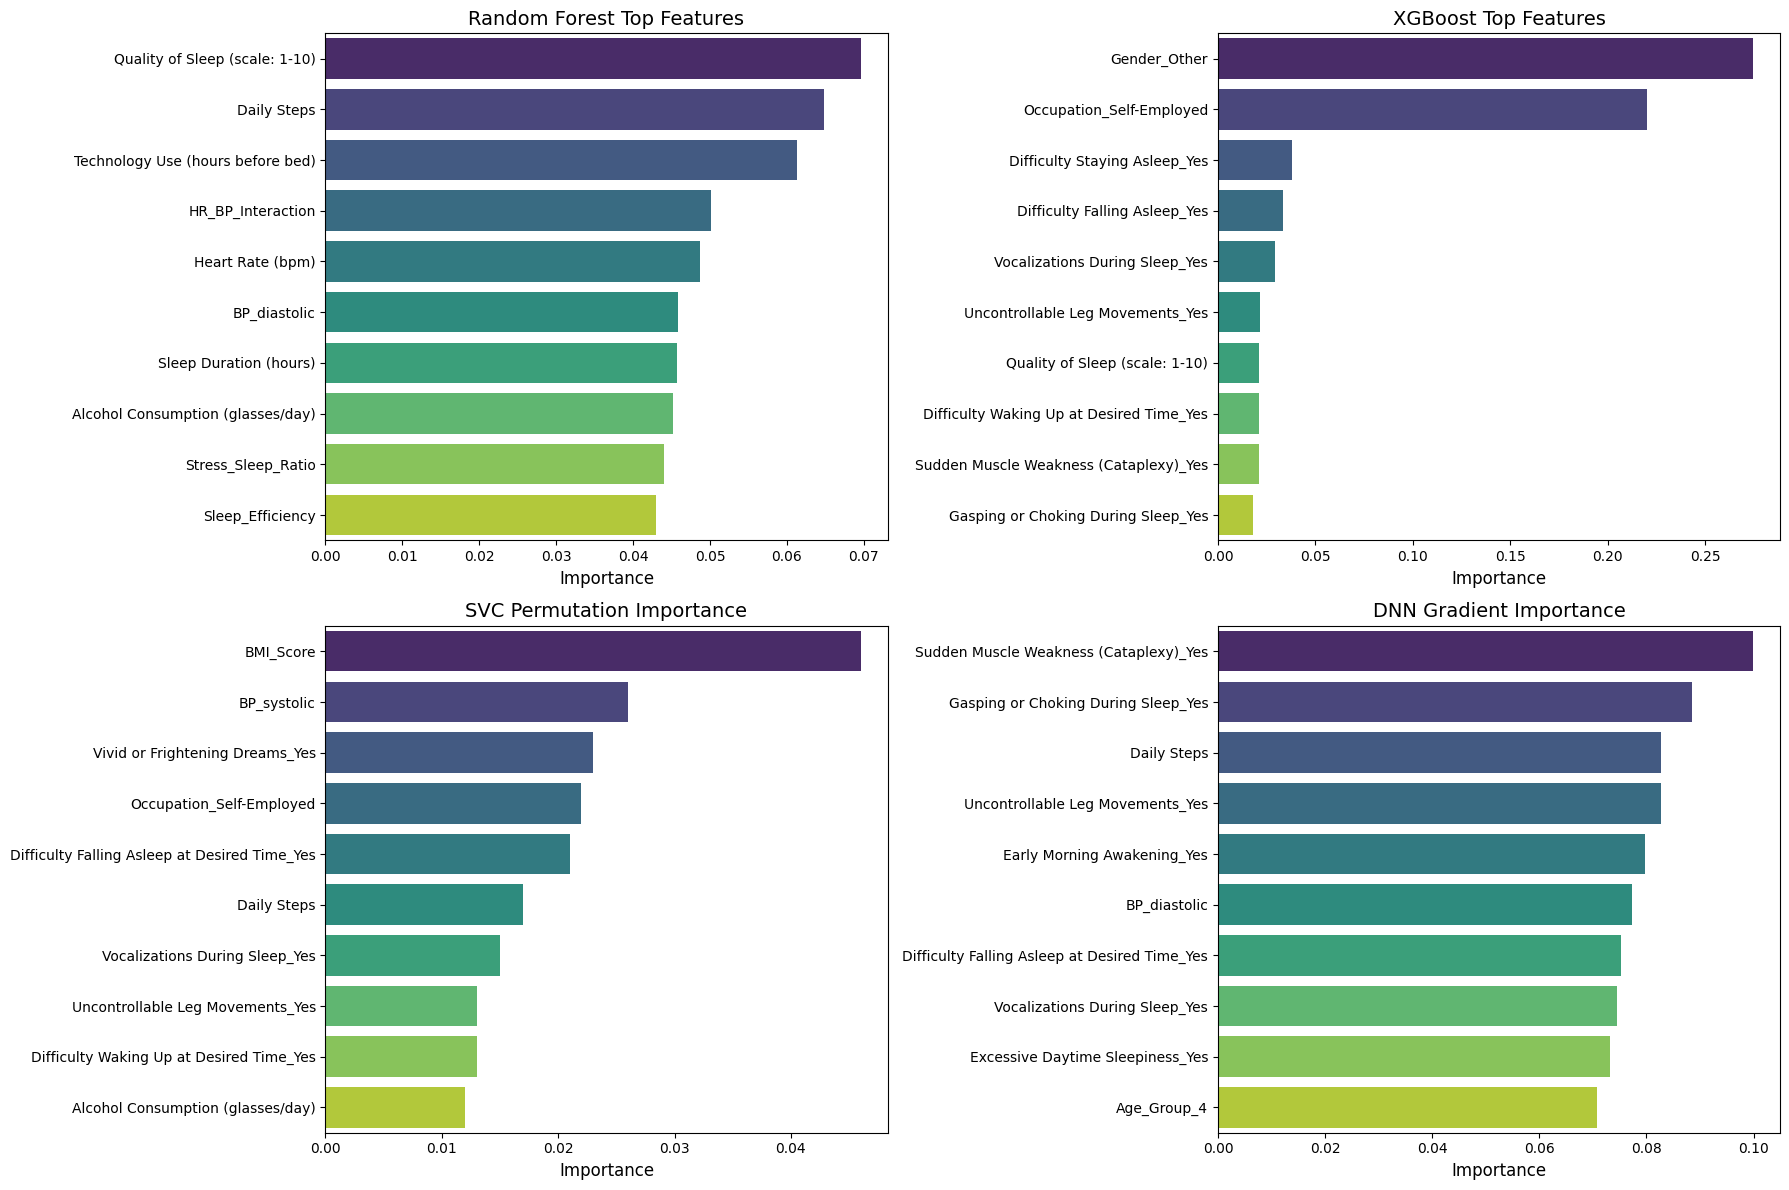

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


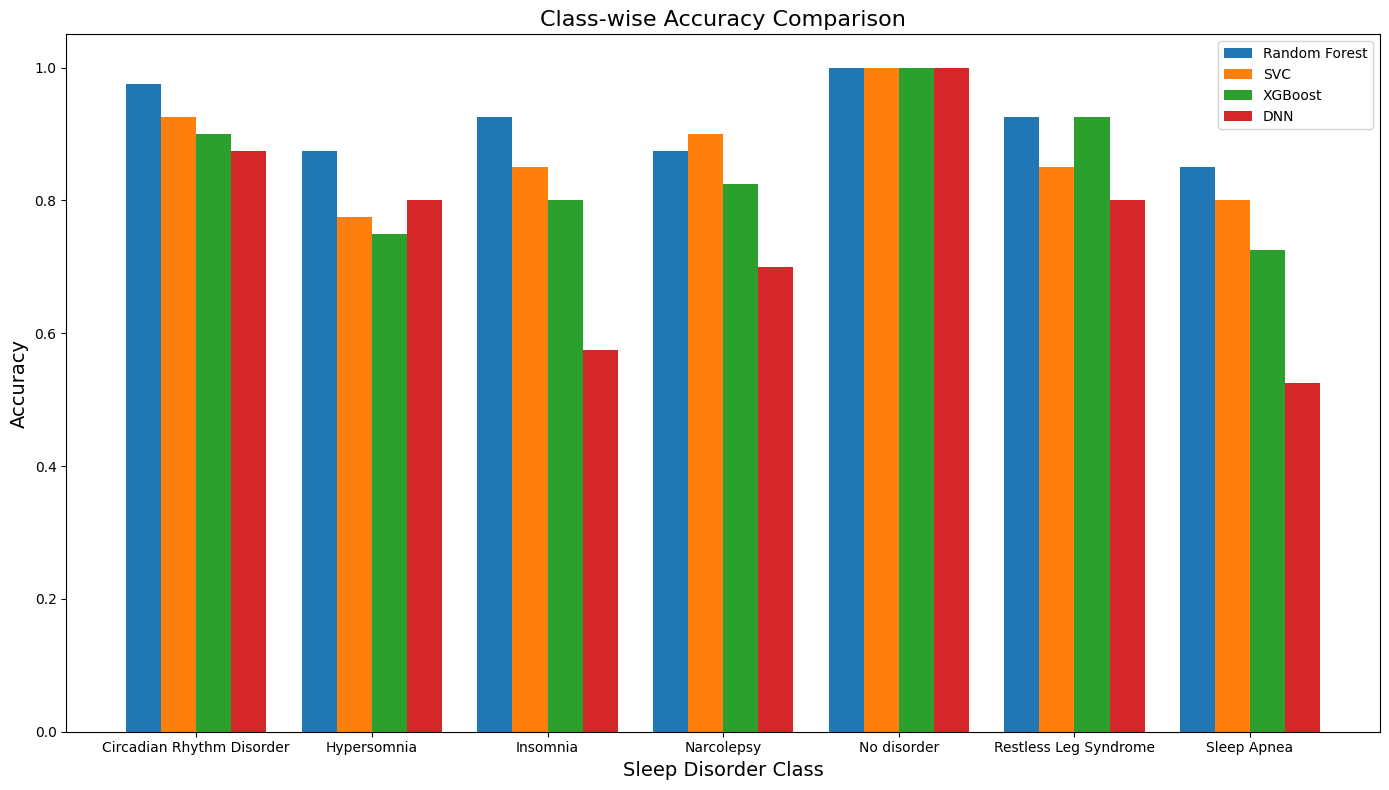

Available history keys: dict_keys([])


<Figure size 1400x500 with 0 Axes>

In [17]:
# ===== Results Visualization =====
def visualize_results(models, X_test, y_test, label_encoder, feature_names=None):
    """Visualize model results with comprehensive plots"""
    
    # If feature_names not provided, create default names
    if feature_names is None:
        feature_names = [f"Feature {i}" for i in range(X_test.shape[1])]
    
    # 1. Model Performance Comparison
    accuracies = []
    model_names = []
    for name, model in models.items():
        if name == "DNN":
            y_pred = np.argmax(model.predict(X_test), axis=1)
        else:
            y_pred = model.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
        model_names.append(name)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=model_names, y=accuracies, palette="viridis")
    plt.title('Model Accuracy Comparison', fontsize=16)
    plt.xlabel('Model', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    plt.ylim(0, 1)
    for i, acc in enumerate(accuracies):
        plt.text(i, acc + 0.02, f"{acc:.3f}", ha='center', fontsize=12)
    plt.show()

    # 2. Separate Confusion Matrices
    for name, model in models.items():
        plt.figure(figsize=(10, 8))
        if name == "DNN":
            y_pred = np.argmax(model.predict(X_test), axis=1)
        else:
            y_pred = model.predict(X_test)
        
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=label_encoder.classes_,
                   yticklabels=label_encoder.classes_)
        plt.title(f'{name} Confusion Matrix', fontsize=16)
        plt.xlabel('Predicted', fontsize=14)
        plt.ylabel('Actual', fontsize=14)
        plt.tight_layout()
        plt.show()

    # 3. Classification Reports
    for name, model in models.items():
        print(f"\n=== {name} Classification Report ===")
        if name == "DNN":
            y_pred = np.argmax(model.predict(X_test), axis=1)
        else:
            y_pred = model.predict(X_test)
        print(classification_report(y_test, y_pred, 
                                  target_names=label_encoder.classes_,
                                  digits=3))

    # 4. Feature Importance Comparison
    plt.figure(figsize=(18, 12))
    plot_num = 1
    
    # 4a. Random Forest Feature Importance
    if 'Random Forest' in models:
        rf_importances = models['Random Forest'].feature_importances_
        top_n = min(10, len(feature_names))
        rf_idx = np.argsort(rf_importances)[-top_n:][::-1]
        
        plt.subplot(2, 2, plot_num)
        sns.barplot(x=rf_importances[rf_idx], y=np.array(feature_names)[rf_idx], palette="viridis")
        plt.title('Random Forest Top Features', fontsize=14)
        plt.xlabel('Importance', fontsize=12)
        plot_num += 1
    
    # 4b. XGBoost Feature Importance
    if 'XGBoost' in models:
        xgb_importances = models['XGBoost'].feature_importances_
        top_n = min(10, len(feature_names))
        xgb_idx = np.argsort(xgb_importances)[-top_n:][::-1]
        
        plt.subplot(2, 2, plot_num)
        sns.barplot(x=xgb_importances[xgb_idx], y=np.array(feature_names)[xgb_idx], palette="viridis")
        plt.title('XGBoost Top Features', fontsize=14)
        plt.xlabel('Importance', fontsize=12)
        plot_num += 1
    
    # 4c. SVC Permutation Importance
    if 'SVC' in models:
        from sklearn.inspection import permutation_importance
        
        # Use a subset for faster computation
        X_test_sample = X_test[:100] if len(X_test) > 100 else X_test
        y_test_sample = y_test[:100] if len(y_test) > 100 else y_test
        
        result = permutation_importance(
            models['SVC'], 
            X_test_sample, 
            y_test_sample, 
            n_repeats=10, 
            random_state=42,
            n_jobs=-1
        )
        
        top_n = min(10, len(feature_names))
        sorted_idx = result.importances_mean.argsort()[-top_n:][::-1]
        
        plt.subplot(2, 2, plot_num)
        sns.barplot(x=result.importances_mean[sorted_idx], 
                   y=np.array(feature_names)[sorted_idx], 
                   palette="viridis")
        plt.title('SVC Permutation Importance', fontsize=14)
        plt.xlabel('Importance', fontsize=12)
        plot_num += 1
    
    # 4d. DNN Gradient Importance (Simplified)
    if 'DNN' in models:
        try:
            import tensorflow as tf
            
            # Use a subset for faster computation
            X_test_sample = X_test[:100] if len(X_test) > 100 else X_test
            input_tensor = tf.convert_to_tensor(X_test_sample, dtype=tf.float32)
            
            with tf.GradientTape() as tape:
                tape.watch(input_tensor)
                predictions = models['DNN'](input_tensor)
                # Get the predicted class probabilities
                class_probs = tf.reduce_max(predictions, axis=1)
            
            # Compute gradients of the max class probability w.r.t inputs
            grads = tape.gradient(class_probs, input_tensor)
            dnn_importances = tf.reduce_mean(tf.abs(grads), axis=0).numpy()
            
            top_n = min(10, len(feature_names))
            sorted_idx = np.argsort(dnn_importances)[-top_n:][::-1]
            
            plt.subplot(2, 2, plot_num)
            sns.barplot(x=dnn_importances[sorted_idx], 
                       y=np.array(feature_names)[sorted_idx], 
                       palette="viridis")
            plt.title('DNN Gradient Importance', fontsize=14)
            plt.xlabel('Importance', fontsize=12)
        except Exception as e:
            print(f"Could not compute DNN feature importance: {str(e)}")
    
    plt.tight_layout()
    plt.show()

    # 5. Class-wise Accuracy Comparison
    plt.figure(figsize=(14, 8))
    class_accuracies = {}
    for name, model in models.items():
        if name == "DNN":
            y_pred = np.argmax(model.predict(X_test), axis=1)
        else:
            y_pred = model.predict(X_test)
        
        cm = confusion_matrix(y_test, y_pred)
        class_acc = cm.diagonal() / cm.sum(axis=1)
        class_accuracies[name] = class_acc
    
    x = np.arange(len(label_encoder.classes_))
    width = 0.8 / len(models)
    
    for i, (name, acc) in enumerate(class_accuracies.items()):
        plt.bar(x + i*width, acc, width, label=name)
    
    plt.title('Class-wise Accuracy Comparison', fontsize=16)
    plt.xlabel('Sleep Disorder Class', fontsize=14)
    plt.ylabel('Accuracy', fontsize=14)
    plt.xticks(x + width*(len(models)-1)/2, label_encoder.classes_)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Get feature names from the preprocessed data
feature_names = X.columns.tolist()

# Execute visualization with feature names
visualize_results(models, X_test_scaled, y_test, label_encoder, feature_names)

# Additional DNN Training Visualization
if 'DNN' in models:
    # Plot training history metrics
    history = dnn_model.history.history
    plt.figure(figsize=(14, 5))
    
    # Check which keys are available in history
    print("Available history keys:", history.keys())
    
    # Plot accuracy if available
    if 'accuracy' in history:
        plt.subplot(1, 2, 1)
        plt.plot(history['accuracy'], label='Train Accuracy')
        if 'val_accuracy' in history:
            plt.plot(history['val_accuracy'], label='Validation Accuracy')
        plt.title('Accuracy Over Epochs', fontsize=14)
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Accuracy', fontsize=12)
        plt.legend()
    
    # Plot loss if available
    if 'loss' in history:
        plt.subplot(1, 2, 2)
        plt.plot(history['loss'], label='Train Loss')
        if 'val_loss' in history:
            plt.plot(history['val_loss'], label='Validation Loss')
        plt.title('Loss Over Epochs', fontsize=14)
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.legend()
    
    plt.tight_layout()
    plt.show()

🔍 Model Interpretability Analysis

🌲 Random Forest Interpretation


100%|===================| 699/700 [03:18<00:00]        

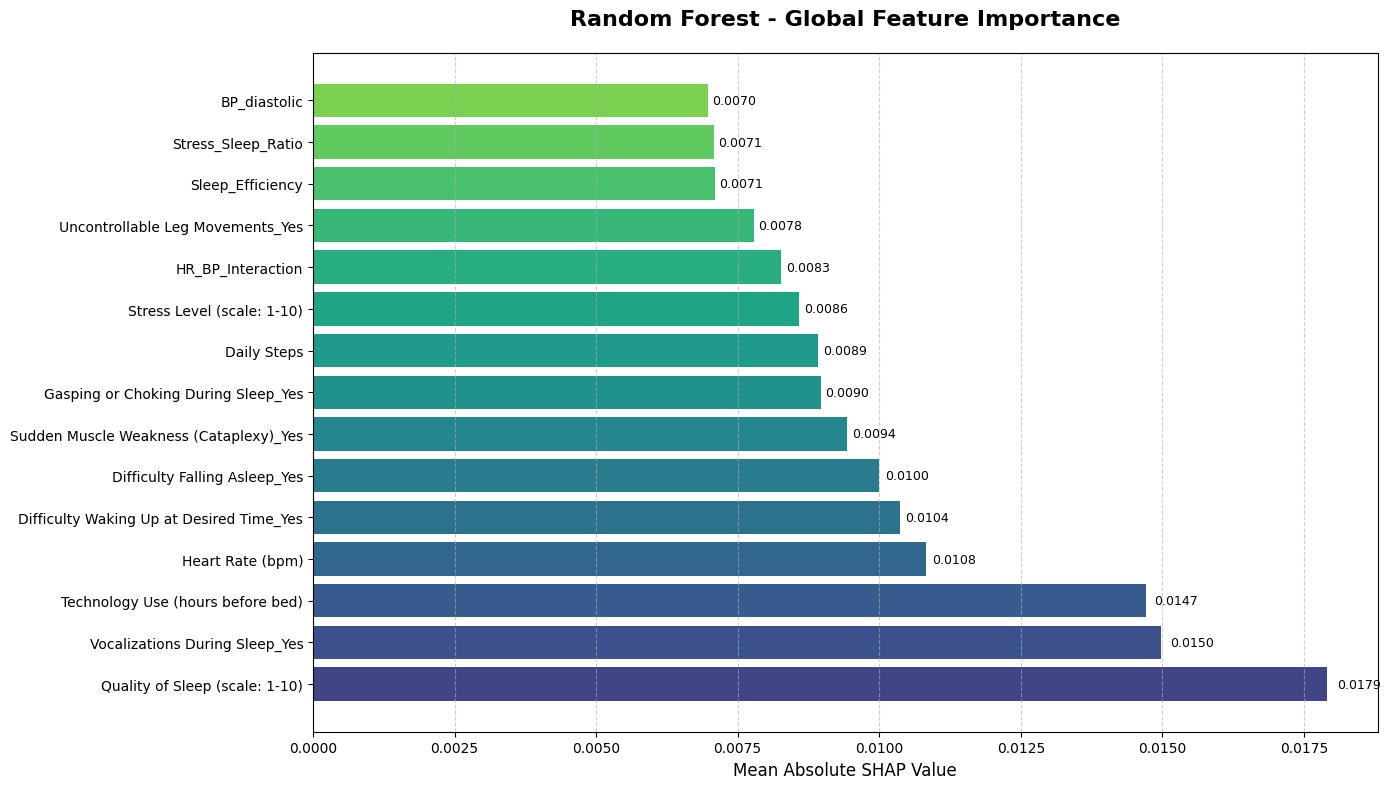

⚠ SHAP beeswarm failed for Random Forest: The beeswarm plot does not support plotting explanations with instances that have more than one dimension!

⚡ XGBoost Interpretation


 99%|===================| 695/700 [04:24<00:01]        

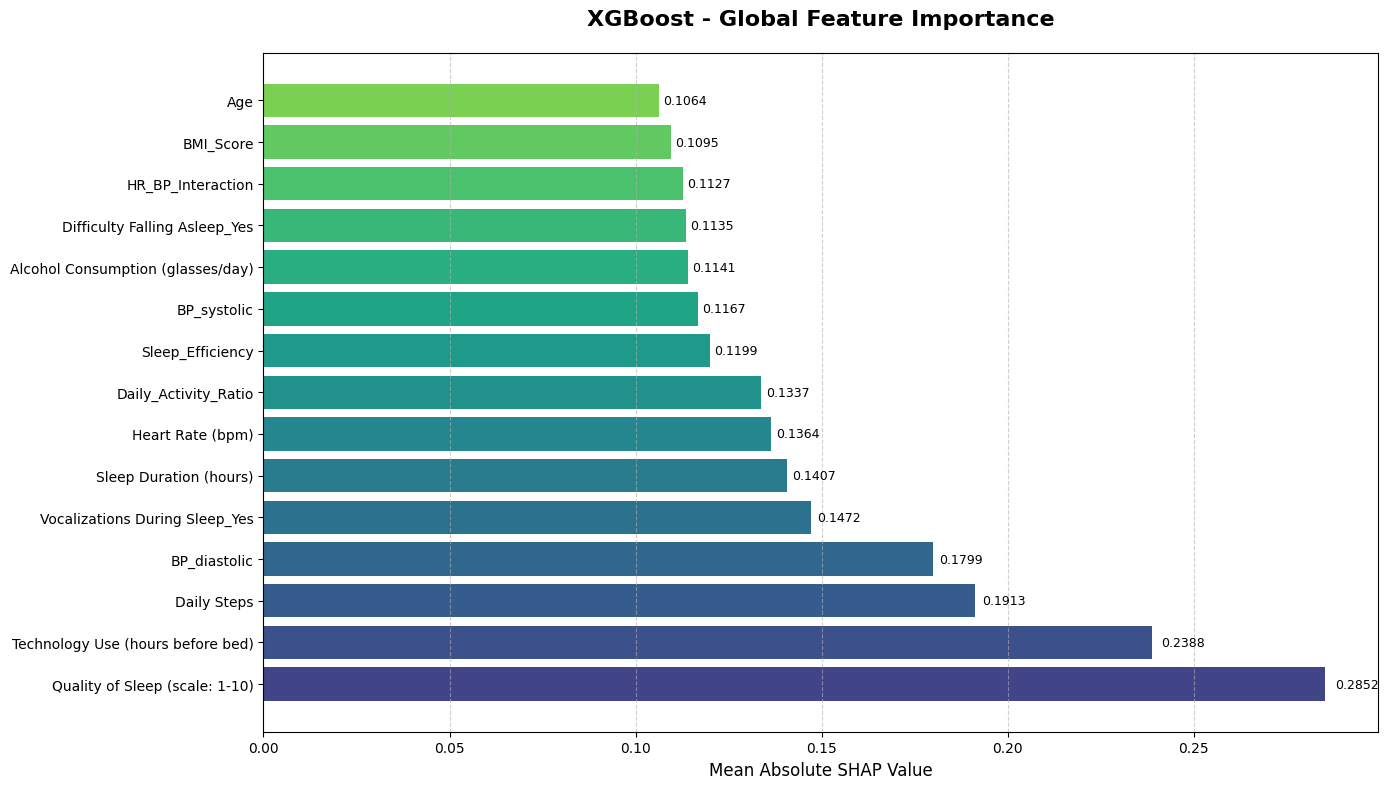

  0%|          | 0/100 [00:00<?, ?it/s]

2026-03-03 12:21:52,223 - INFO - num_full_subsets = 1
2026-03-03 12:21:52,224 - INFO - remaining_weight_vector = array([0.17443519, 0.12030013, 0.09344742, 0.07752675, 0.06709046,
       0.05980635, 0.054511  , 0.05056092, 0.04757323, 0.04530784,
       0.0436088 , 0.04237292, 0.04153219, 0.04104357, 0.04088325])
2026-03-03 12:21:52,225 - INFO - num_paired_subset_sizes = 15
2026-03-03 12:21:52,262 - INFO - weight_left = 0.74368134682094


⚠ SHAP beeswarm failed for XGBoost: The beeswarm plot does not support plotting explanations with instances that have more than one dimension!

🔵 SVC Interpretation


2026-03-03 12:22:03,107 - INFO - np.sum(w_aug) = 32.0
2026-03-03 12:22:03,108 - INFO - np.sum(self.kernelWeights) = 1.0
2026-03-03 12:22:03,114 - INFO - phi = array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
       -0.01042605,  0.        , -0.00492156,  0.        ,  0.        ,
        0.        ,  0.        , -0.00797965,  0.        , -0.01595267,
        0.        ,  0.        ,  0.        , -0.00591878,  0.        ,
        0.        , -0.00625367,  0.        , -0.01275253, -0.0144521 ,
        0.        ,  0.        , -0.01348159, -0.00782416,  0.        ,
        0.        ,  0.        ])
2026-03-03 12:22:03,114 - INFO - np.sum(w_aug) = 32.0
2026-03-03 12:22:03,115 - INFO - np.sum(self.kernelWeights) = 1.0
2026-03-03 12:22:03,119 - INFO - phi = array([ 0.        ,  0.        ,  0.        ,  0.        , -0.00548171,
        0.        ,  0.        ,  0.        ,  0.        ,  0.01583863,
       -0.02535081,  0.        , -0.02412112, -0.00570606,  0.        ,


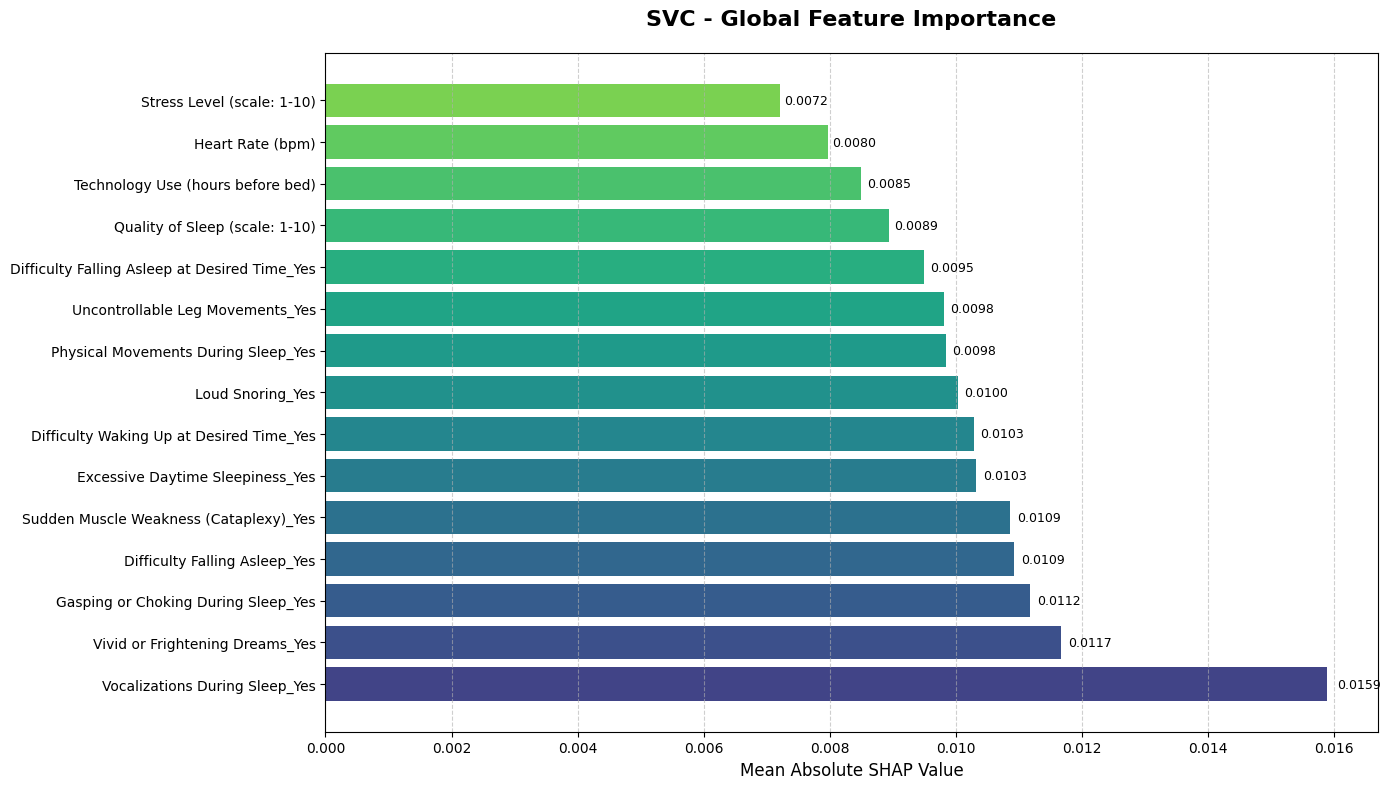


🧠 Neural Network Interpretation


PermutationExplainer explainer: 101it [00:30,  2.78it/s]                         


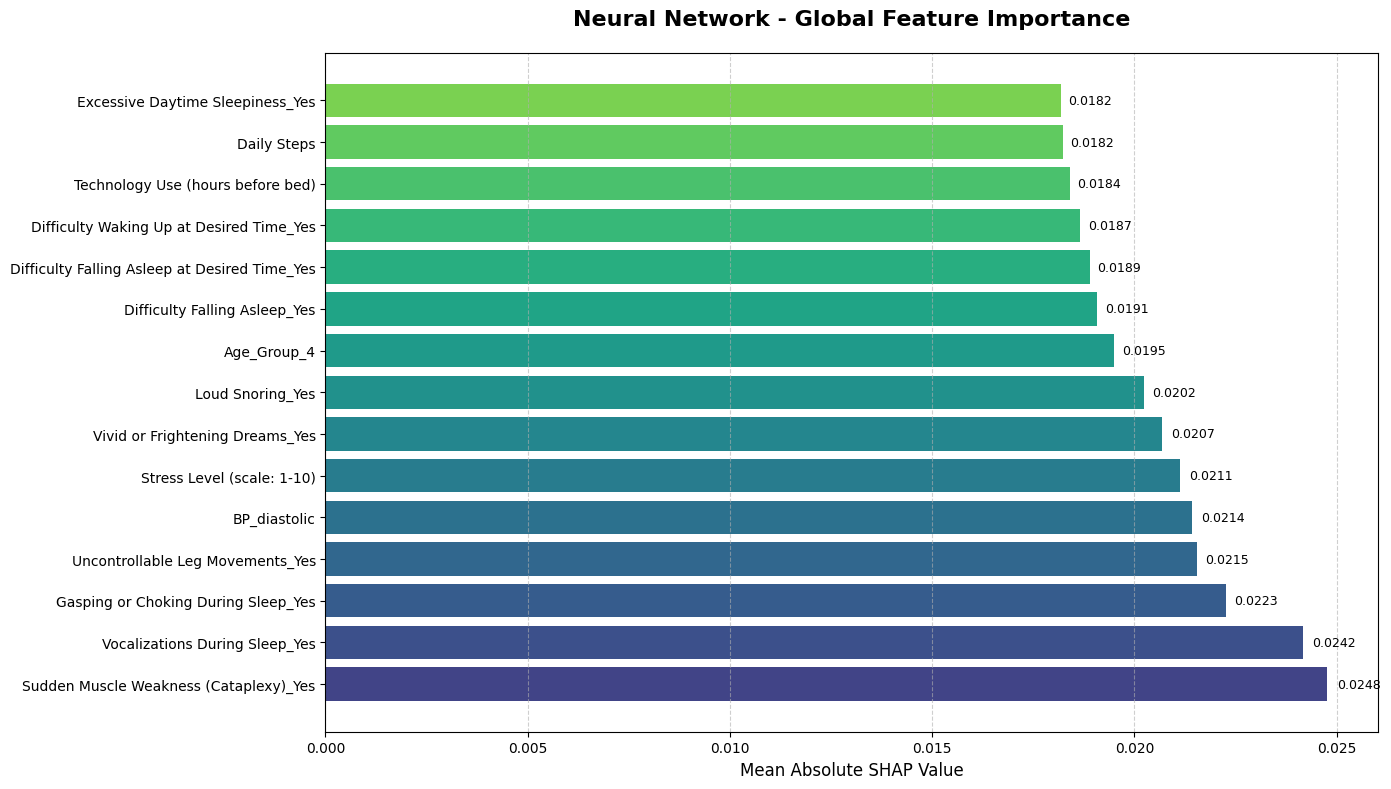

⚠ SHAP beeswarm failed for Neural Network: The beeswarm plot does not support plotting explanations with instances that have more than one dimension!


<Figure size 1400x600 with 0 Axes>

In [18]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import warnings
import logging
import sys
import os
from matplotlib.colors import LinearSegmentedColormap

# Configure logging to suppress INFO messages
logging.basicConfig(level=logging.WARNING)

def explain_model(model, X_train, X_test, feature_names, model_name="", max_samples=100):
    """
    Enhanced SHAP visualizations with better colors and SVC support.
    Shows comprehensive plots for all model types.
    """
    plt.close('all')
    warnings.filterwarnings('ignore')
    
    try:
        # Create custom colormap
        colors = ["#ff7f0e", "#ffffff", "#1f77b4"]  # Orange to White to Blue
        cmap = LinearSegmentedColormap.from_list("impact_cmap", colors)
        
        # Special handling for different model types
        if hasattr(model, '_is_keras_model'):  # DNN
            def predict_wrapper(X):
                return model.predict(X, verbose=0)
            explainer = shap.KernelExplainer(predict_wrapper, shap.sample(X_train, 100))
        elif hasattr(model, 'kernel'):  # SVC
            explainer = shap.KernelExplainer(model.predict_proba, shap.sample(X_train, 100))
        else:  # RF, XGBoost, etc.
            explainer = shap.Explainer(model, X_train[:max_samples])
        
        # Calculate SHAP values - suppress output by capturing it
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            old_stdout = sys.stdout
            sys.stdout = open(os.devnull, 'w')
            try:
                shap_values = explainer(X_test[:max_samples])
            finally:
                sys.stdout = old_stdout
        
        # Create main summary plot
        plt.figure(figsize=(14, 8))
        if len(shap_values.shape) == 3:  # Multi-class
            # Aggregate across classes
            global_shap = np.mean(np.abs(shap_values.values), axis=(0,2))
            top_features = np.argsort(global_shap)[-15:][::-1]
            
            # Enhanced bar plot
            bars = plt.barh(range(len(top_features)), 
                          global_shap[top_features],
                          color=plt.cm.viridis(np.linspace(0.2, 0.8, len(top_features))))
            
            plt.yticks(range(len(top_features)), 
                      [feature_names[i] for i in top_features],
                      fontsize=10)
            plt.title(f"{model_name} - Global Feature Importance", 
                     fontsize=16, pad=20, fontweight='bold')
            plt.xlabel("Mean Absolute SHAP Value", fontsize=12)
            plt.grid(axis='x', linestyle='--', alpha=0.6)
            
            # Add value annotations
            for i, bar in enumerate(bars):
                width = bar.get_width()
                plt.text(width*1.01, i, f"{width:.4f}", 
                        va='center', fontsize=9)
                
        else:  # Single output
            shap.summary_plot(shap_values, X_test[:max_samples],
                            feature_names=feature_names,
                            plot_type="dot",
                            max_display=15,
                            cmap=cmap,
                            show=False)
            plt.title(f"{model_name} - Feature Impact", 
                     fontsize=16, pad=20, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        # Additional detailed plot for non-SVC models
        if not hasattr(model, 'kernel'):
            try:
                plt.figure(figsize=(14, 6))
                shap.plots.beeswarm(shap_values, 
                                  max_display=15, 
                                  show=False,
                                  color=cmap)
                plt.title(f"{model_name} - Detailed Feature Impacts", 
                         fontsize=16, pad=20, fontweight='bold')
                plt.tight_layout()
                plt.show()
            except Exception as beeswarm_error:
                print(f"⚠ SHAP beeswarm failed for {model_name}: {str(beeswarm_error)}")
            
        return shap_values
    
    except Exception as e:
        print(f"⚠ SHAP failed for {model_name}: {str(e)}")
        return None

# Get feature names
feature_names = (X.columns.tolist() if hasattr(X, 'columns') 
                else [f"Feature_{i}" for i in range(X.shape[1])])

# Explain all available models
print("🔍 Model Interpretability Analysis")
print("="*50)

models_to_explain = {
    'Random Forest': 'best_rf',
    'XGBoost': 'best_xgb',
    'SVC': 'best_svc',  # Added SVC
    'Neural Network': 'dnn_model'
}

for name, var in models_to_explain.items():
    if var in locals():
        print(f"\n{'🌲' if 'Forest' in name else '⚡' if 'XGB' in name else '🧠' if 'Neural' in name else '🔵'} {name} Interpretation")
        explain_model(eval(var), X_train_scaled, X_test_scaled,
                    feature_names, name, max_samples=100)